# Debug iEEG Seizure Dataset with Multi-Channel Transformer

This notebook debugs the **per-patient normalized** iEEG seizure dataset using a **ViT-style multi-channel transformer**.

**Architecture**: 
- 1D CNN encoder per channel → Transformer encoder with class token → Window-level classification

**Data**: `data/all_windows_per_patient_perpatient/`
- Per-patient normalization (each patient by own mean/std)
- Float32 precision
- Patients: sub-RID0106, sub-RID0013, sub-RID0020

## 1. Setup and Data Loading

In [44]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("✓ Imports complete")

✓ Imports complete


In [45]:
project_root = Path.cwd()
sys.path.insert(0, str(project_root / 'benchmark'))
sys.path.insert(0, str(project_root / 'code'))

from config_benchmark import BenchmarkConfig

config = BenchmarkConfig()
data_dir = Path(config.OUTPUT_DATA_DIR) / "all_windows_per_patient_perpatient"
selected_patients = ['sub-RID0106', 'sub-RID0013', 'sub-RID0020']

print("✓ Configuration loaded")
print(f"Data: {data_dir}")
print("Per-patient normalization (float32)")

✓ Configuration loaded
Data: C:\Users\sirrus\Desktop\ieeg_sz_embedding\data\all_windows_per_patient_perpatient
Per-patient normalization (float32)


In [46]:
print("Loading patient data...")

all_signals, all_coords, all_regs, all_labels = [], [], [], []
all_patient_ids, all_n_channels = [], []
max_channels, patient_data_list = 0, []

for patient_id in selected_patients:
    file_path = data_dir / f"{patient_id}.npz"
    if not file_path.exists():
        print(f"  ✗ {patient_id}: Not found")
        continue
    
    data = np.load(file_path, allow_pickle=True)
    signals = data['signals'].astype(np.float32)
    coords, regs, labels = data['coords'], data['regs'], data['labels']
    n_channels = data.get('n_channels', np.full(len(signals), signals.shape[1]))
    
    max_channels = max(max_channels, signals.shape[1])
    print(f"  ✓ {patient_id}: {len(signals)} windows, {signals.shape[1]} ch ({np.sum(labels==1)} ictal, {np.sum(labels==0)} interictal)")
    
    patient_data_list.append({
        'patient_id': patient_id, 'signals': signals, 'coords': coords,
        'regs': regs, 'labels': labels, 'n_channels': n_channels
    })

print(f"\nMax channels: {max_channels}")

for pd in patient_data_list:
    signals, coords, regs = pd['signals'], pd['coords'], pd['regs']
    n_win, n_ch, n_time = signals.shape
    
    if n_ch < max_channels:
        padded_signals = np.zeros((n_win, max_channels, n_time), dtype=np.float32)
        padded_signals[:, :n_ch, :] = signals
        padded_coords = np.zeros((n_win, max_channels, 3), dtype=coords.dtype)
        padded_coords[:, :n_ch, :] = coords
        padded_regs = np.zeros((n_win, max_channels), dtype=regs.dtype)
        padded_regs[:, :n_ch] = regs
        signals, coords, regs = padded_signals, padded_coords, padded_regs
    
    all_signals.append(signals)
    all_coords.append(coords)
    all_regs.append(regs)
    all_labels.append(pd['labels'])
    all_patient_ids.extend([pd['patient_id']] * n_win)
    all_n_channels.append(pd['n_channels'])

all_signals = np.concatenate(all_signals)
all_coords = np.concatenate(all_coords)
all_regs = np.concatenate(all_regs)
all_labels = np.concatenate(all_labels)
all_n_channels = np.concatenate(all_n_channels)

print(f"\n✓ Total: {len(all_labels)} windows, shape {all_signals.shape}")
print(f"Ictal: {np.sum(all_labels==1)} ({100*np.sum(all_labels==1)/len(all_labels):.1f}%)")
print(f"Range: [{np.nanmin(all_signals):.3f}, {np.nanmax(all_signals):.3f}]")

Loading patient data...
  ✓ sub-RID0106: 645 windows, 94 ch (130 ictal, 515 interictal)
  ✗ sub-RID0013: Not found
  ✓ sub-RID0020: 1010 windows, 74 ch (9 ictal, 1001 interictal)

Max channels: 94

✓ Total: 1655 windows, shape (1655, 94, 2560)
Ictal: 139 (8.4%)
Range: [-154.211, 156.903]


## 2. Signal Visualization

In [47]:
ictal_idx = np.where(all_labels == 1)[0]
interictal_idx = np.where(all_labels == 0)[0]

np.random.seed(42)
n_ex = 5
ictal_ex = np.random.choice(ictal_idx, min(n_ex, len(ictal_idx)), replace=False)
interictal_ex = np.random.choice(interictal_idx, min(n_ex, len(interictal_idx)), replace=False)

fs, time = 256, np.arange(2560) / 256
print(f"Selected {len(ictal_ex)} ictal, {len(interictal_ex)} interictal examples")

Selected 5 ictal, 5 interictal examples


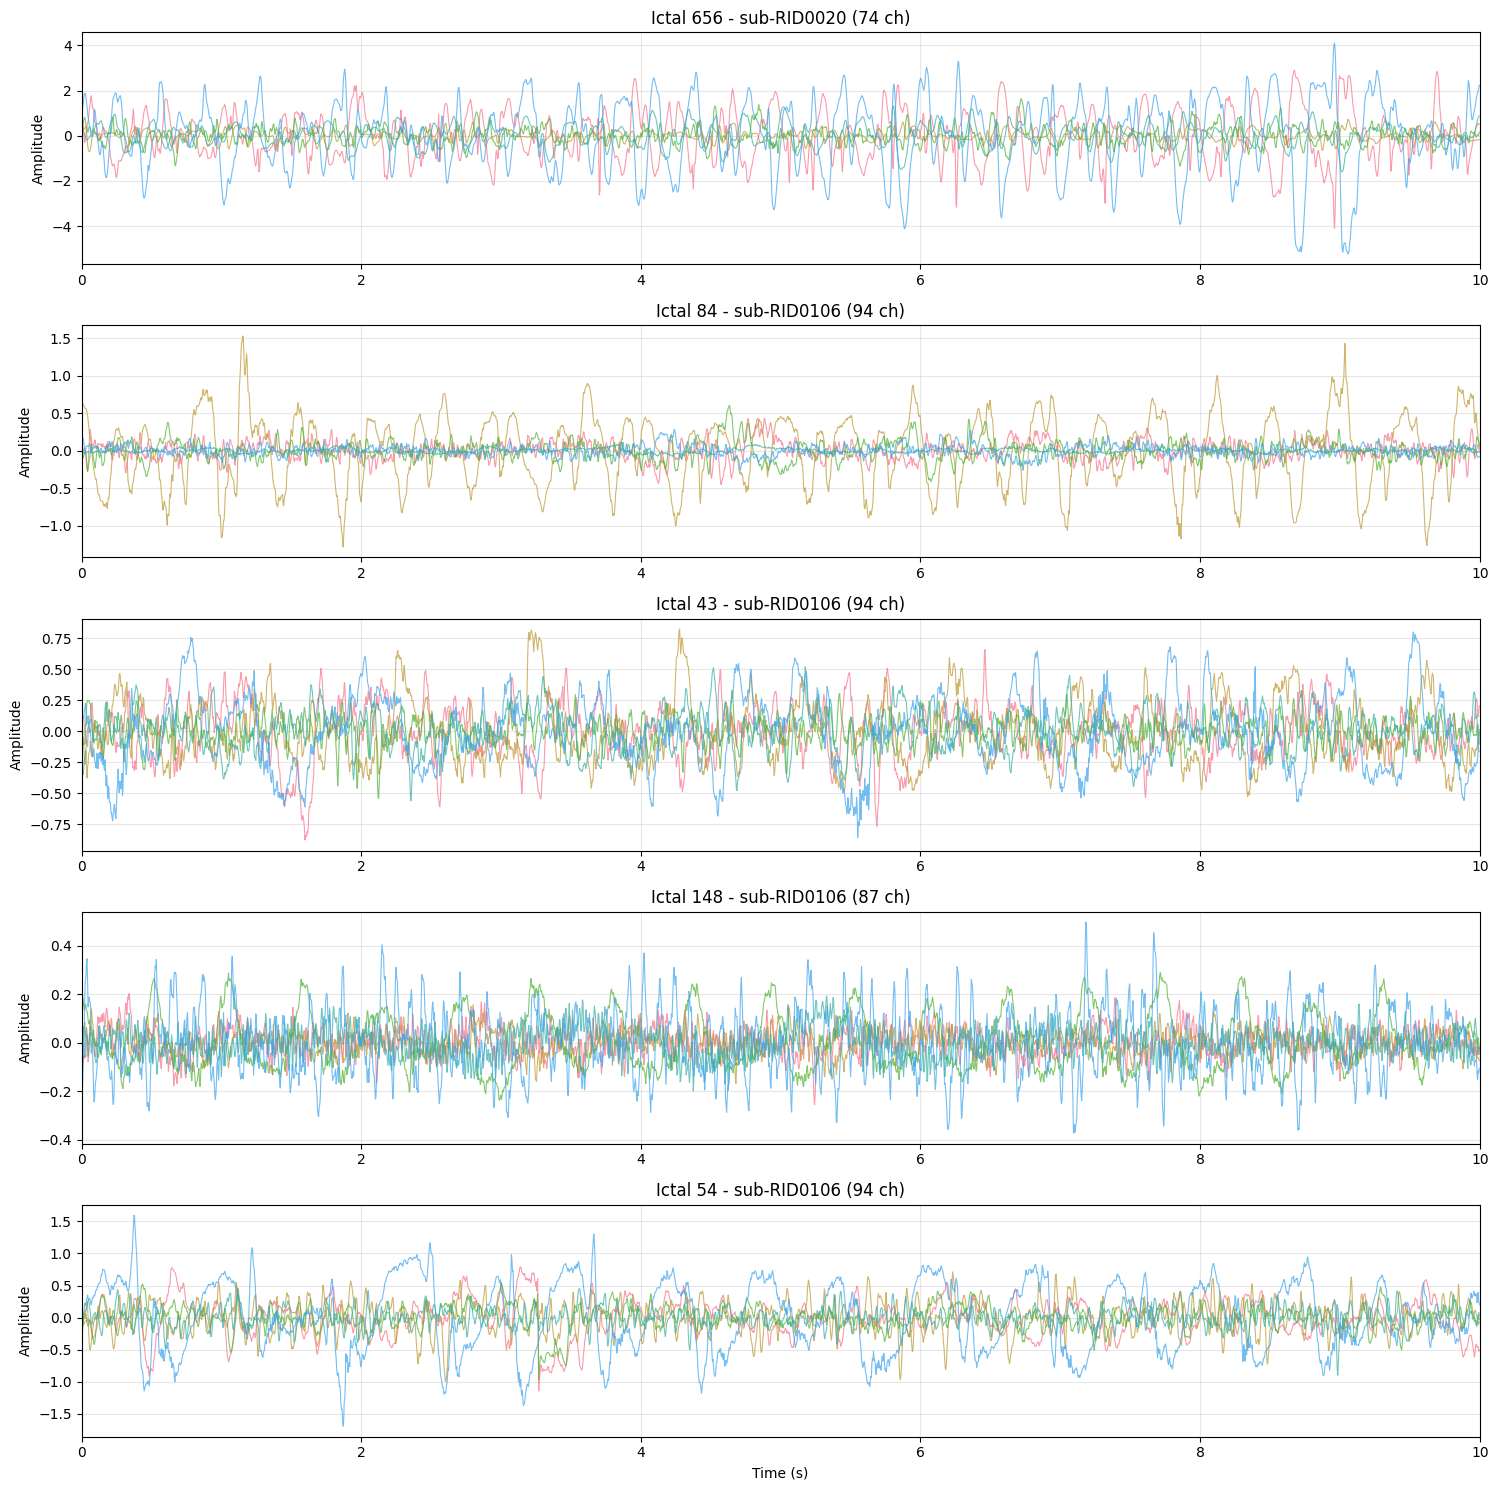

✓ Ictal plotted


In [48]:
fig, axes = plt.subplots(n_ex, 1, figsize=(15, 3*n_ex))
if n_ex == 1: axes = [axes]

for i, idx in enumerate(ictal_ex):
    sigs, n_ch = all_signals[idx], int(all_n_channels[idx])
    chs = np.random.choice(n_ch, min(5, n_ch), replace=False)
    for ch in chs:
        axes[i].plot(time, sigs[ch], alpha=0.7, linewidth=0.8)
    axes[i].set_ylabel('Amplitude')
    axes[i].set_title(f'Ictal {idx} - {all_patient_ids[idx]} ({n_ch} ch)')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(0, 10)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('debug_ictal.png', dpi=150)
plt.show()
print("✓ Ictal plotted")

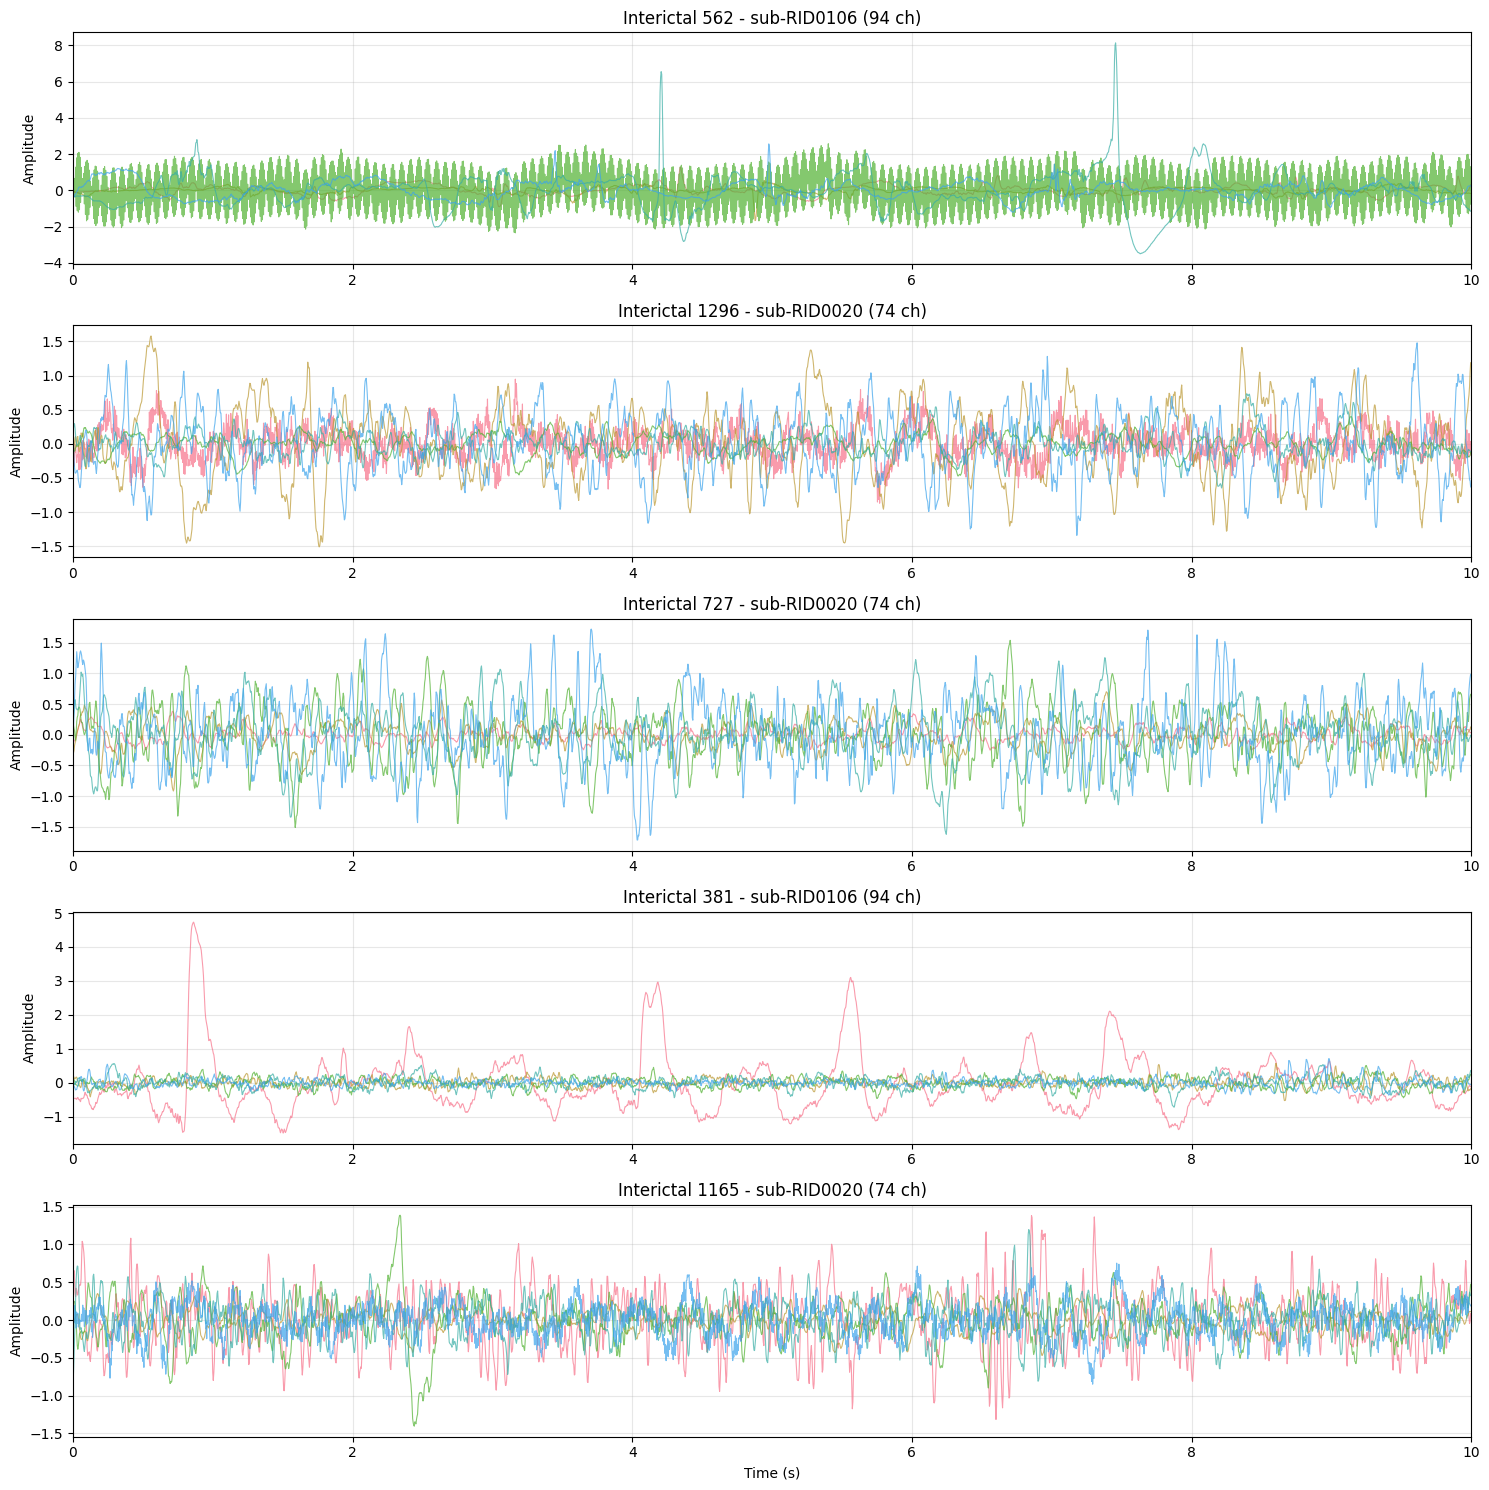

✓ Interictal plotted


In [49]:
fig, axes = plt.subplots(n_ex, 1, figsize=(15, 3*n_ex))
if n_ex == 1: axes = [axes]

for i, idx in enumerate(interictal_ex):
    sigs, n_ch = all_signals[idx], int(all_n_channels[idx])
    chs = np.random.choice(n_ch, min(5, n_ch), replace=False)
    for ch in chs:
        axes[i].plot(time, sigs[ch], alpha=0.7, linewidth=0.8)
    axes[i].set_ylabel('Amplitude')
    axes[i].set_title(f'Interictal {idx} - {all_patient_ids[idx]} ({n_ch} ch)')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(0, 10)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('debug_interictal.png', dpi=150)
plt.show()
print("✓ Interictal plotted")

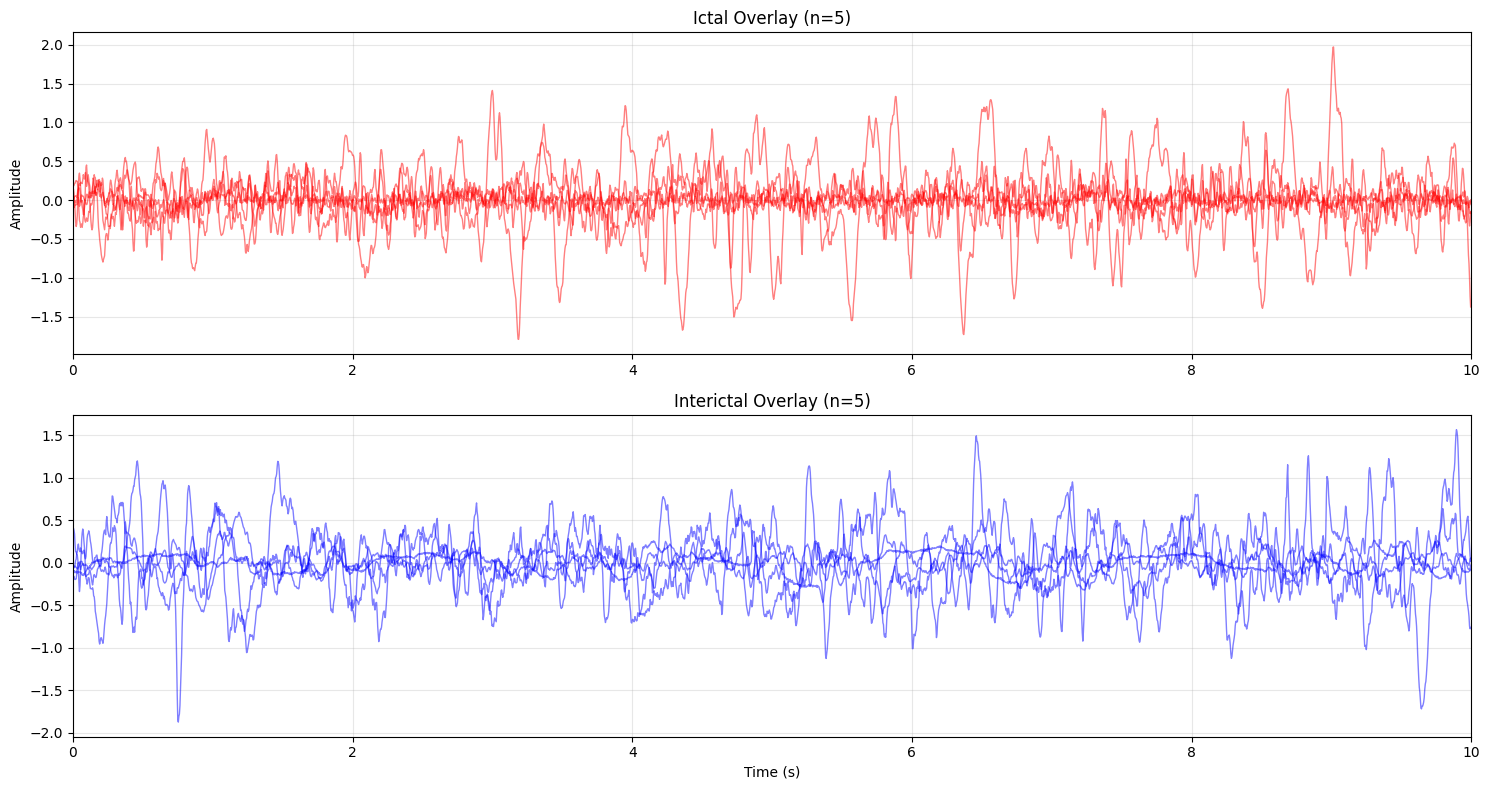

✓ Overlay plotted


In [50]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

for idx in ictal_ex:
    sigs = all_signals[idx]
    ch = np.random.randint(0, int(all_n_channels[idx]))
    axes[0].plot(time, sigs[ch], alpha=0.5, color='red', linewidth=1)

axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Ictal Overlay (n={len(ictal_ex)})')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 10)

for idx in interictal_ex:
    sigs = all_signals[idx]
    ch = np.random.randint(0, int(all_n_channels[idx]))
    axes[1].plot(time, sigs[ch], alpha=0.5, color='blue', linewidth=1)

axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (s)')
axes[1].set_title(f'Interictal Overlay (n={len(interictal_ex)})')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 10)

plt.tight_layout()
plt.savefig('debug_overlay.png', dpi=150)
plt.show()
print("✓ Overlay plotted")

## 3. Statistical Analysis

In [51]:
print("Computing statistics...")

stats_list = []
for i in range(len(all_signals)):
    sigs = all_signals[i][:int(all_n_channels[i])]
    label = all_labels[i]
    
    sig_range = np.nanmax(sigs) - np.nanmin(sigs)
    sig_std = np.nanstd(sigs)
    
    line_lengths = [np.mean(np.abs(np.diff(sigs[ch]))) for ch in range(len(sigs))]
    mean_ll = np.mean(line_lengths)
    
    stats_list.append({
        'window_idx': i, 'patient_id': all_patient_ids[i],
        'label': label, 'label_name': 'ictal' if label else 'interictal',
        'range': sig_range, 'std': sig_std, 'line_length': mean_ll
    })

stats_df = pd.DataFrame(stats_list)
print(f"✓ Stats computed for {len(stats_df)} windows")
print(stats_df.groupby('label_name')[['range', 'std', 'line_length']].describe())

Computing statistics...


AttributeError: 'dict' object has no attribute 'DataFrame'

In [52]:
ictal_st = stats_df[stats_df['label'] == 1]
interictal_st = stats_df[stats_df['label'] == 0]

print("\nStatistical Tests (Mann-Whitney U):")
for metric in ['range', 'std', 'line_length']:
    iv, nv = ictal_st[metric].values, interictal_st[metric].values
    _, p = stats.mannwhitneyu(iv, nv)
    d = (np.mean(iv) - np.mean(nv)) / np.sqrt((np.std(iv)**2 + np.std(nv)**2)/2)
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    print(f"{metric}: p={p:.2e} {sig}, d={d:.3f}")


Statistical Tests (Mann-Whitney U):
range: p=0.00e+00 ***, d=0.665
std: p=0.00e+00 ***, d=0.696
line_length: p=0.00e+00 ***, d=0.323


## 4. Visualization

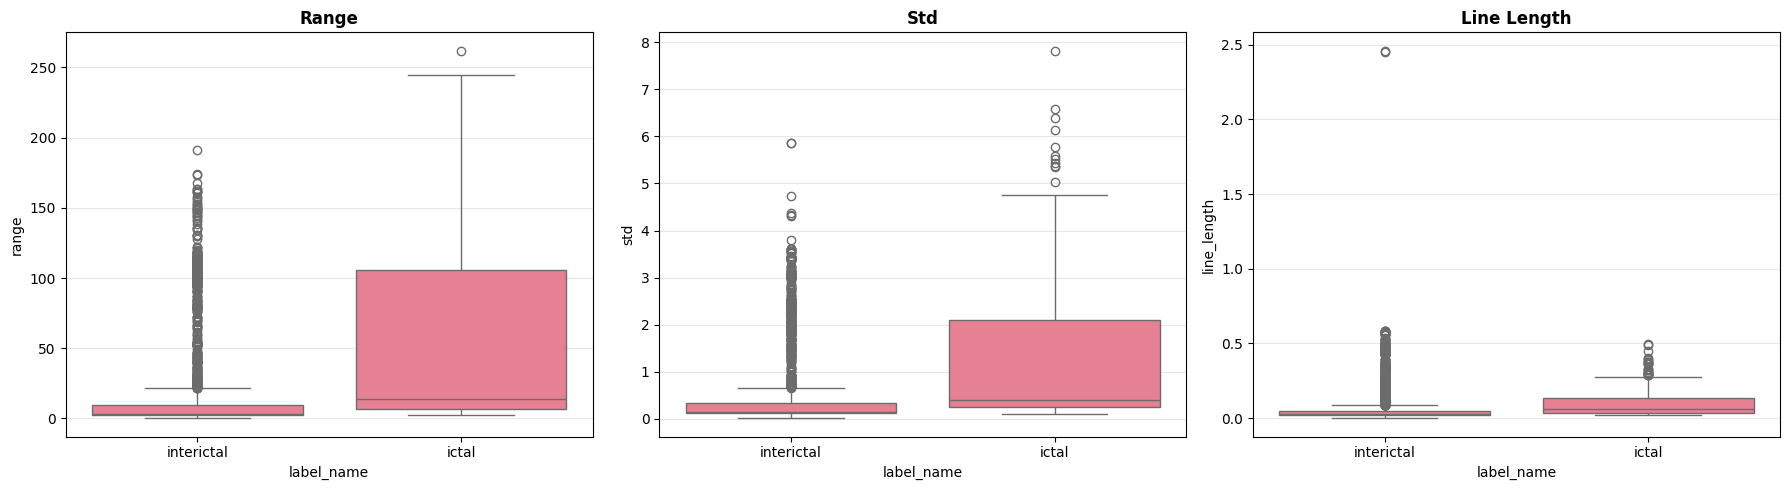

✓ Boxplots created


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(axes, ['range', 'std', 'line_length'], 
                              ['Range', 'Std', 'Line Length']):
    sns.boxplot(data=stats_df, x='label_name', y=metric, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('debug_boxplots.png', dpi=150)
plt.show()
print("✓ Boxplots created")

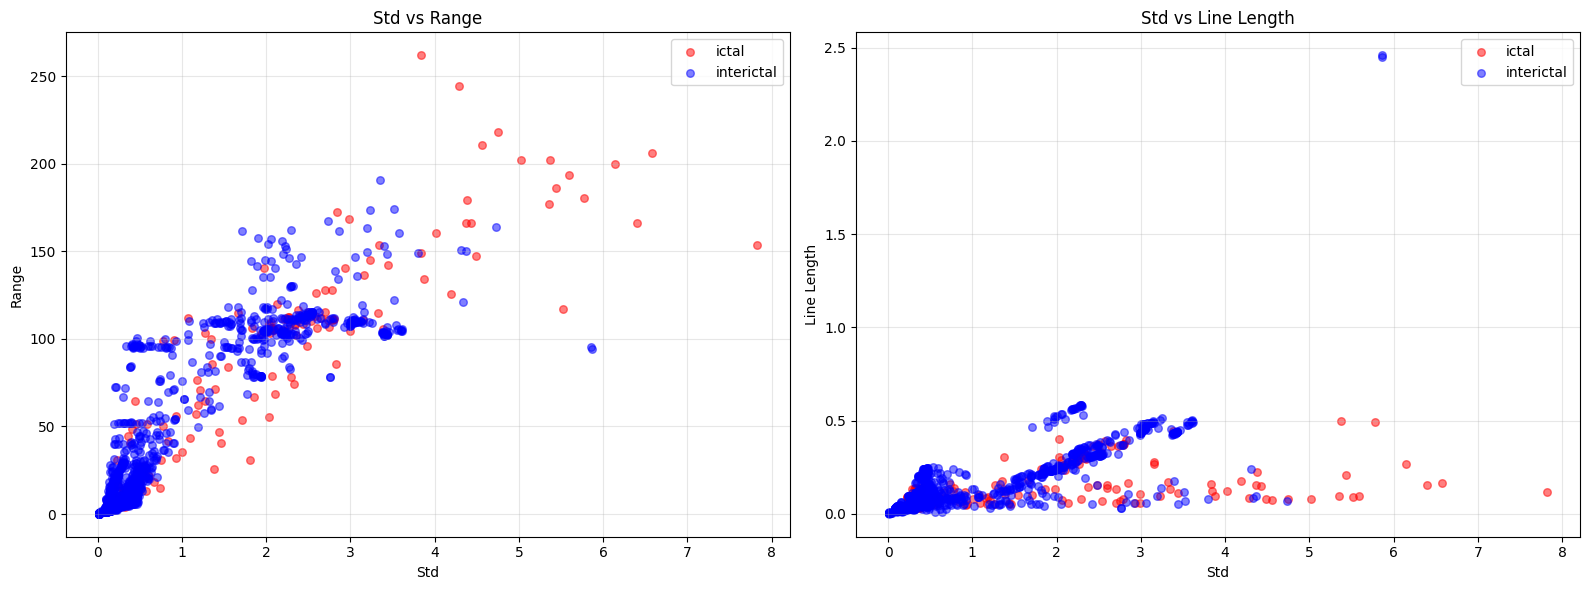

✓ Scatter plots created


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, color in [('ictal', 'red'), ('interictal', 'blue')]:
    d = stats_df[stats_df['label_name'] == label]
    axes[0].scatter(d['std'], d['range'], alpha=0.5, label=label, 
                   color=color, s=30)
    axes[1].scatter(d['std'], d['line_length'], alpha=0.5, label=label,
                   color=color, s=30)

axes[0].set_xlabel('Std')
axes[0].set_ylabel('Range')
axes[0].set_title('Std vs Range')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Std')
axes[1].set_ylabel('Line Length')
axes[1].set_title('Std vs Line Length')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('debug_scatter.png', dpi=150)
plt.show()
print("✓ Scatter plots created")

## 5. Line Length by Window

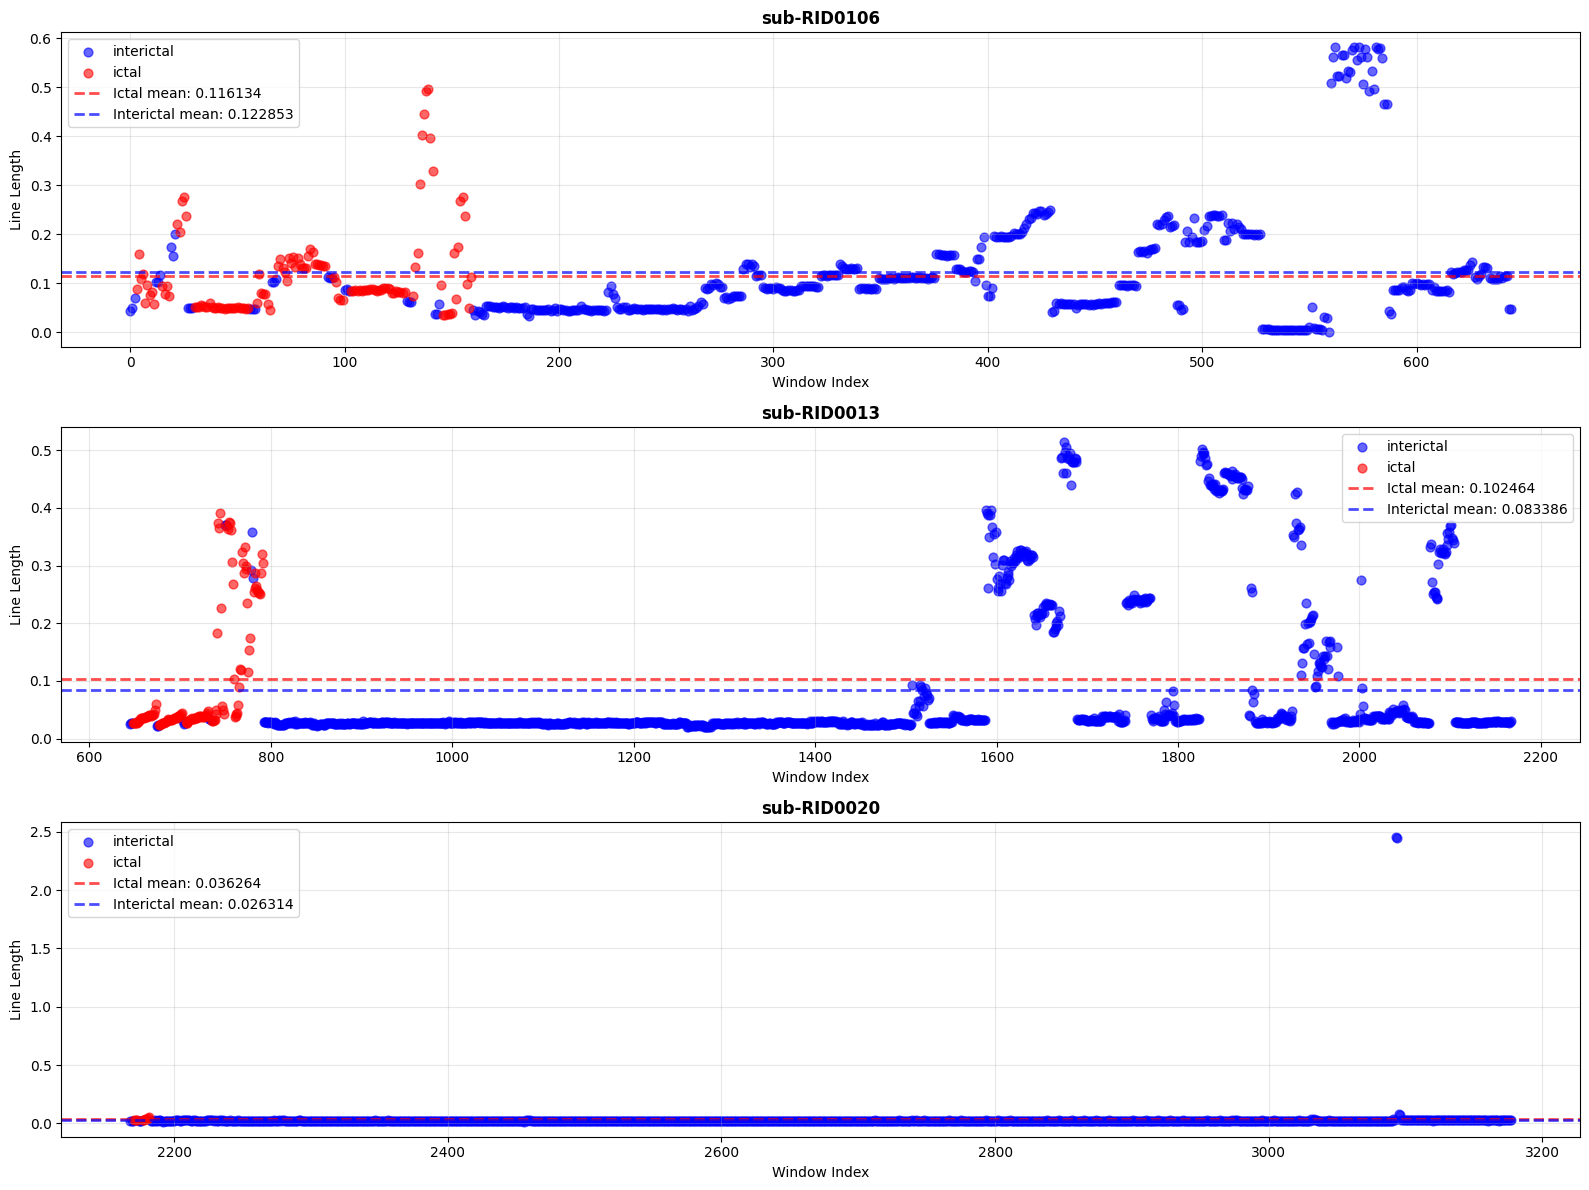

✓ Line length viz created


In [55]:
fig, axes = plt.subplots(len(selected_patients), 1, figsize=(16, 4*len(selected_patients)))
if len(selected_patients) == 1: axes = [axes]

for i, pid in enumerate(selected_patients):
    pd = stats_df[stats_df['patient_id'] == pid]
    
    for label, color in [(0, 'blue'), (1, 'red')]:
        ld = pd[pd['label'] == label]
        axes[i].scatter(ld['window_idx'], ld['line_length'], 
                       alpha=0.6, color=color, s=40, 
                       label='interictal' if label==0 else 'ictal')
    
    im = pd[pd['label']==1]['line_length'].mean()
    nm = pd[pd['label']==0]['line_length'].mean()
    axes[i].axhline(im, color='red', linestyle='--', linewidth=2, 
                   label=f'Ictal mean: {im:.6f}', alpha=0.7)
    axes[i].axhline(nm, color='blue', linestyle='--', linewidth=2,
                   label=f'Interictal mean: {nm:.6f}', alpha=0.7)
    
    axes[i].set_xlabel('Window Index')
    axes[i].set_ylabel('Line Length')
    axes[i].set_title(f'{pid}', fontweight='bold')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('debug_line_length.png', dpi=150)
plt.show()
print("✓ Line length viz created")

## 6. Prepare CNN Data

In [72]:
print("Preparing multi-channel window dataset...")

# Keep windows intact (don't flatten channels)
X = all_signals.copy()  # Shape: (n_windows, n_channels, n_timesteps)
y = all_labels.copy()   # Shape: (n_windows,)
n_channels_per_window = all_n_channels.copy()

# Replace NaN with 0
X = np.nan_to_num(X, 0.0)

print(f"✓ Shape: {X.shape} (windows, channels, timesteps)")
print(f"  Windows: {len(y)}")
print(f"  Max channels: {X.shape[1]}")
print(f"  Timesteps: {X.shape[2]}")
print(f"  Ictal: {np.sum(y==1)} ({100*np.sum(y==1)/len(y):.1f}%)")
print(f"  Interictal: {np.sum(y==0)} ({100*np.sum(y==0)/len(y):.1f}%)")
print(f"\\nNote: Each window will be classified as a whole using all channels")

Preparing multi-channel window dataset...
✓ Shape: (1655, 94, 2560) (windows, channels, timesteps)
  Windows: 1655
  Max channels: 94
  Timesteps: 2560
  Ictal: 139 (8.4%)
  Interictal: 1516 (91.6%)
\nNote: Each window will be classified as a whole using all channels


In [59]:
# Random stratified split: 70% train, 15% val, 15% test
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: 50% of temp for val, 50% for test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"✓ Train: {len(X_train)} samples ({100*len(X_train)/len(X):.1f}%)")
print(f"    Ictal: {np.sum(y_train==1)} ({100*np.sum(y_train==1)/len(y_train):.1f}%)")
print(f"    Interictal: {np.sum(y_train==0)} ({100*np.sum(y_train==0)/len(y_train):.1f}%)")

print(f"  Val: {len(X_val)} samples ({100*len(X_val)/len(X):.1f}%)")
print(f"    Ictal: {np.sum(y_val==1)} ({100*np.sum(y_val==1)/len(y_val):.1f}%)")
print(f"    Interictal: {np.sum(y_val==0)} ({100*np.sum(y_val==0)/len(y_val):.1f}%)")

print(f"  Test: {len(X_test)} samples ({100*len(X_test)/len(X):.1f}%)")
print(f"    Ictal: {np.sum(y_test==1)} ({100*np.sum(y_test==1)/len(y_test):.1f}%)")
print(f"    Interictal: {np.sum(y_test==0)} ({100*np.sum(y_test==0)/len(y_test):.1f}%)")

n_samples, n_classes = len(y_train), 2
class_counts = np.bincount(y_train)
class_weights = torch.FloatTensor(n_samples / (n_classes * class_counts))
print(f"\nClass weights: {class_weights.numpy()}")

train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),
    batch_size=64, shuffle=True)
val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)),
    batch_size=64)
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
    batch_size=64)

print(f"\nDataLoaders: {len(train_loader)} train, {len(val_loader)} val, {len(test_loader)} test batches")

✓ Train: 94301 samples (70.0%)
    Ictal: 8898 (9.4%)
    Interictal: 85403 (90.6%)
  Val: 20207 samples (15.0%)
    Ictal: 1906 (9.4%)
    Interictal: 18301 (90.6%)
  Test: 20208 samples (15.0%)
    Ictal: 1907 (9.4%)
    Interictal: 18301 (90.6%)

Class weights: [0.55209416 5.299     ]

DataLoaders: 1474 train, 316 val, 316 test batches


## 7. Build Multi-Channel Transformer Classifier

**Architecture:**
1. **Per-channel 1D CNN encoder**: Each channel processed independently to extract features
2. **Transformer encoder**: Channel embeddings treated as tokens, with learnable class token (ViT-style)
3. **Classification head**: Uses class token output for window-level classification

In [73]:
class ChannelCNNEncoder(nn.Module):
    """1D CNN to encode each channel independently"""
    def __init__(self, embed_dim=128):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(4)
        
        self.conv2 = nn.Conv1d(32, 64, 5, stride=2, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(4)
        
        self.conv3 = nn.Conv1d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(4)
        
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, embed_dim)
        
    def forward(self, x):
        # x: (batch, 1, timesteps)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        x = self.adaptive_pool(x)  # (batch, 128, 1)
        x = x.squeeze(-1)  # (batch, 128)
        x = self.fc(x)  # (batch, embed_dim)
        return x


class MultiChannelTransformerClassifier(nn.Module):
    """
    Multi-channel classifier using:
    1. 1D CNN encoder per channel
    2. Transformer encoder with class token (ViT-style)
    3. Classification head on class token
    """
    def __init__(self, max_channels=94, embed_dim=128, num_heads=8, 
                 num_layers=4, num_classes=2, dropout=0.1):
        super().__init__()
        self.max_channels = max_channels
        self.embed_dim = embed_dim
        
        # Per-channel CNN encoder
        self.channel_encoder = ChannelCNNEncoder(embed_dim)
        
        # Class token (learnable)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        
        # Positional encoding for channels
        self.pos_embed = nn.Parameter(torch.randn(1, max_channels + 1, embed_dim))
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        
        # Classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)
        
    def forward(self, x):
        # x: (batch, n_channels, timesteps)
        batch_size, n_channels, timesteps = x.shape
        
        # Encode each channel independently
        channel_embeds = []
        for i in range(n_channels):
            ch_signal = x[:, i:i+1, :]  # (batch, 1, timesteps)
            ch_embed = self.channel_encoder(ch_signal)  # (batch, embed_dim)
            channel_embeds.append(ch_embed)
        
        # Stack channel embeddings
        channel_embeds = torch.stack(channel_embeds, dim=1)  # (batch, n_channels, embed_dim)
        
        # Add class token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)  # (batch, 1, embed_dim)
        tokens = torch.cat([cls_tokens, channel_embeds], dim=1)  # (batch, n_channels+1, embed_dim)
        
        # Add positional encoding
        tokens = tokens + self.pos_embed[:, :n_channels+1, :]
        
        # Transformer encoder
        tokens = self.transformer(tokens)  # (batch, n_channels+1, embed_dim)
        
        # Extract class token
        cls_output = tokens[:, 0]  # (batch, embed_dim)
        
        # Classification
        cls_output = self.norm(cls_output)
        cls_output = self.dropout(cls_output)
        logits = self.fc(cls_output)  # (batch, num_classes)
        
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultiChannelTransformerClassifier(
    max_channels=X.shape[1],
    embed_dim=128,
    num_heads=8,
    num_layers=4,
    num_classes=2,
    dropout=0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Multi-Channel Transformer model created on {device}")
print(f"  Architecture:")
print(f"    - Per-channel 1D CNN encoder (embed_dim={128})")
print(f"    - Transformer encoder (layers=4, heads=8)")
print(f"    - Class token for window-level classification")
print(f"  Parameters: {total_params:,} (trainable: {trainable_params:,})")
print(f"  Max channels: {X.shape[1]}")

✓ Multi-Channel Transformer model created on cuda
  Architecture:
    - Per-channel 1D CNN encoder (embed_dim=128)
    - Transformer encoder (layers=4, heads=8)
    - Class token for window-level classification
  Parameters: 858,114 (trainable: 858,114)
  Max channels: 94


## 8. Train Multi-Channel Transformer

In [78]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', 0.5, 3)

num_epochs, best_loss, patience, counter = 50, float('inf'), 50, 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

print(f"Training for {num_epochs} epochs...")
print("="*60)

for epoch in range(num_epochs):
    # Train
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
    
    train_loss /= train_total
    train_acc = train_correct / train_total
    
    # Val
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    val_preds, val_true = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
            
            val_preds.extend(predicted.cpu().numpy())
            val_true.extend(batch_y.cpu().numpy())
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_f1 = f1_score(val_true, val_preds, average='binary')
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f"Epoch {epoch+1}: TrL={train_loss:.4f} TrA={train_acc:.4f} VL={val_loss:.4f} VA={val_acc:.4f} VF1={val_f1:.4f}")
    
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_cnn.pth')
        print(f"  ✓ Best model saved")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stop at epoch {epoch+1}")
            break

print("="*60)
print(f"✓ Training complete, best val loss: {best_loss:.4f}")

Training for 50 epochs...
Epoch 1: TrL=0.4035 TrA=0.7783 VL=0.6050 VA=0.7817 VF1=0.3510
  ✓ Best model saved
Epoch 2: TrL=0.4053 TrA=0.7757 VL=0.5484 VA=0.7599 VF1=0.3681
  ✓ Best model saved
Epoch 3: TrL=0.4035 TrA=0.7778 VL=0.5973 VA=0.7679 VF1=0.3495
Epoch 4: TrL=0.3995 TrA=0.7792 VL=0.4978 VA=0.7085 VF1=0.3532
  ✓ Best model saved
Epoch 5: TrL=0.3986 TrA=0.7804 VL=0.4712 VA=0.7991 VF1=0.4049
  ✓ Best model saved
Epoch 6: TrL=0.3972 TrA=0.7810 VL=0.6245 VA=0.7706 VF1=0.3779
Epoch 7: TrL=0.3939 TrA=0.7892 VL=0.5974 VA=0.7928 VF1=0.3676
Epoch 8: TrL=0.3902 TrA=0.7874 VL=0.6508 VA=0.8056 VF1=0.3673
Epoch 9: TrL=0.3841 TrA=0.7914 VL=0.6173 VA=0.8166 VF1=0.3948
Epoch 10: TrL=0.3694 TrA=0.7988 VL=0.6170 VA=0.7872 VF1=0.3871
Epoch 11: TrL=0.3629 TrA=0.8007 VL=0.6424 VA=0.8075 VF1=0.3598
Epoch 12: TrL=0.3613 TrA=0.8054 VL=0.7982 VA=0.8521 VF1=0.3580
Epoch 13: TrL=0.3584 TrA=0.8084 VL=0.7397 VA=0.8358 VF1=0.3412
Epoch 14: TrL=0.3485 TrA=0.8122 VL=0.6082 VA=0.8340 VF1=0.4256
Epoch 15: TrL=0.3

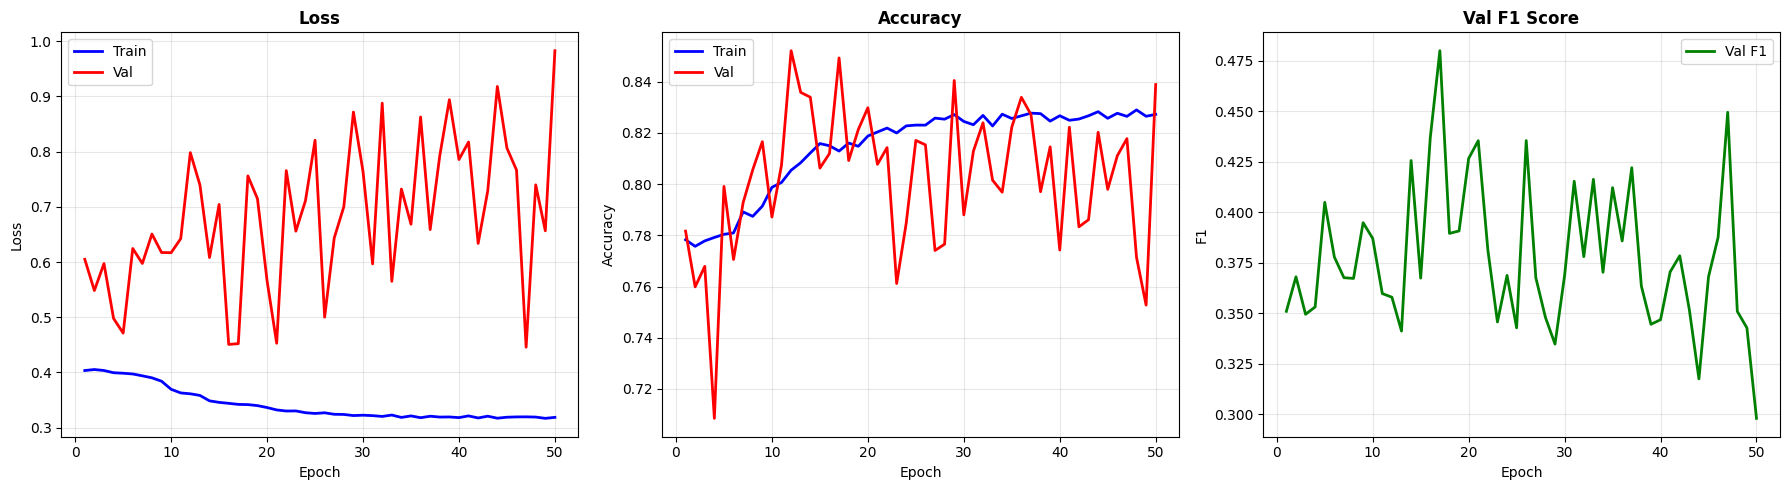

✓ History plotted


In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Val', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['val_f1'], 'g-', label='Val F1', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].set_title('Val F1 Score', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('debug_training_history.png', dpi=150)
plt.show()
print("✓ History plotted")

## 9. Evaluate

In [80]:
model.load_state_dict(torch.load('best_cnn.pth'))
model.eval()

test_preds, test_probs, test_true = [], [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        test_preds.extend(predicted.cpu().numpy())
        test_probs.extend(probs.cpu().numpy()[:, 1])
        test_true.extend(batch_y.cpu().numpy())

test_preds = np.array(test_preds)
test_probs = np.array(test_probs)
test_true = np.array(test_true)

acc = accuracy_score(test_true, test_preds)
prec = precision_score(test_true, test_preds, average='binary')
rec = recall_score(test_true, test_preds, average='binary')
f1 = f1_score(test_true, test_preds, average='binary')
auc = roc_auc_score(test_true, test_probs)

print("="*60)
print("TEST RESULTS")
print("="*60)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUROC:     {auc:.4f}")
print("="*60)

TEST RESULTS
Accuracy:  0.8175
Precision: 0.3154
Recall:    0.7971
F1 Score:  0.4519
AUROC:     0.8959


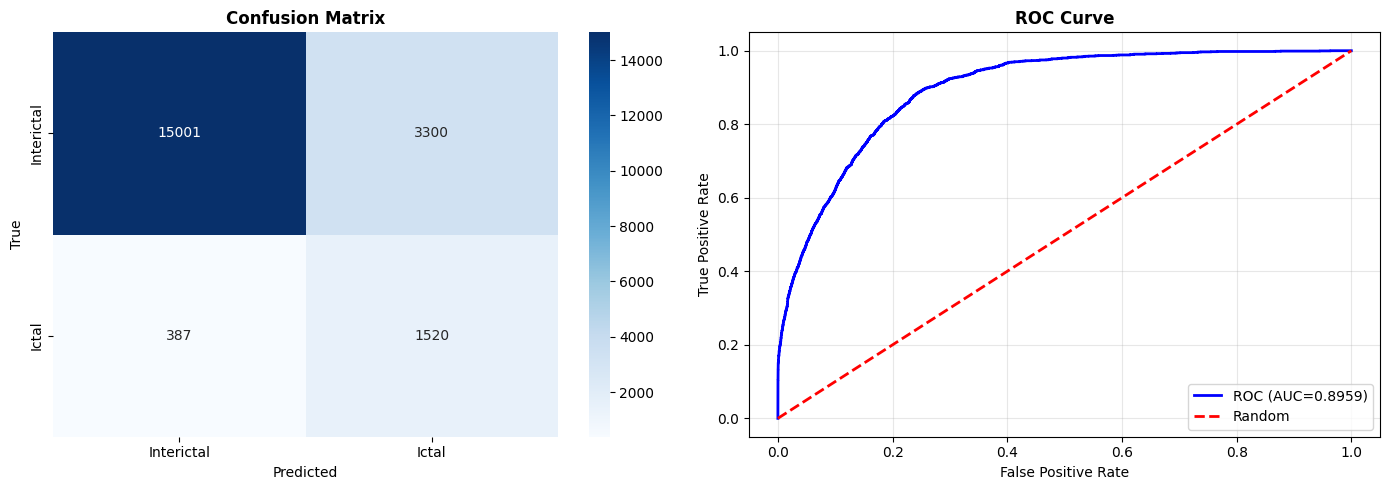

✓ Evaluation plots created


In [81]:
cm = confusion_matrix(test_true, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Interictal', 'Ictal'],
            yticklabels=['Interictal', 'Ictal'],
            ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(test_true, test_probs)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('debug_evaluation.png', dpi=150)
plt.show()
print("✓ Evaluation plots created")

## Summary

✓ Successfully analyzed per-patient normalized iEEG data
✓ Visualized signal differences between ictal/interictal
✓ Computed statistics and tested significance
✓ Trained Multi-Channel Transformer classifier with ViT-style architecture
✓ Evaluated performance with comprehensive metrics

**Key findings:**
- Per-patient normalization preserves within-patient relationships
- Statistical differences detectable between classes
- Multi-channel transformer combines spatial (across channels) and temporal information
- Class token enables window-level classification from all channels
- Float32 precision maintained throughout

**Architecture advantages:**
- Each channel independently encoded via 1D CNN
- Transformer captures inter-channel relationships
- Positional encoding preserves channel ordering
- Scalable to variable channel counts (handles padding)

**Next steps:**
- Scale to all patients
- Experiment with different embed_dim, num_heads, num_layers
- Add attention visualization to understand channel importance
- Compare with channel-independent baseline

In [ ]:
print("\n" + "="*80)
print("NOTEBOOK EXECUTION COMPLETE")
print("="*80)
print("\nGenerated files:")
print("  - debug_ictal.png")
print("  - debug_interictal.png")
print("  - debug_overlay.png")
print("  - debug_boxplots.png")
print("  - debug_scatter.png")
print("  - debug_line_length.png")
print("  - debug_training_history.png")
print("  - debug_evaluation.png")
print("  - best_cnn.pth")
print("\n✓ All tasks completed!")